<a href="https://colab.research.google.com/github/gre1wy/Machine_Learning/blob/main/lab5/lab5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from collections import Counter

In [3]:
from sklearn.cluster import KMeans

# Part 1

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'stellar-classification-dataset-sdss17' dataset.
Path to dataset files: /kaggle/input/stellar-classification-dataset-sdss17


In [5]:
csv_file = os.path.join(path, "star_classification.csv")
df = pd.read_csv(csv_file)

In [6]:
df.drop(['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'MJD', 'fiber_ID', 'plate'], axis=1, inplace=True)
col = df.pop("class")
df.insert(0, "class", col)
cols = ['g', 'z', 'u']
df = df[~(df[cols] == -9999).any(axis=1)]

In [7]:
df["class"]=[0 if i == "GALAXY" else 1 if i == "STAR" else 2 for i in df["class"]]

In [8]:
def rem_outliers(df, factor=1.5):
    dataset = df.copy()
    initial_rows = dataset.shape[0]

    for col in dataset.select_dtypes(include='number').columns:
        q1 = dataset[col].quantile(0.25)
        q3 = dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        dataset = dataset[(dataset[col] >= lower) & (dataset[col] <= upper)]

    removed = initial_rows - dataset.shape[0]
    return dataset, removed
df_clean, deleted = rem_outliers(df)
print("Number of outliers deleted are : ", deleted)

Number of outliers deleted are :  9399


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90600 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   class     90600 non-null  int64  
 1   alpha     90600 non-null  float64
 2   delta     90600 non-null  float64
 3   u         90600 non-null  float64
 4   g         90600 non-null  float64
 5   r         90600 non-null  float64
 6   i         90600 non-null  float64
 7   z         90600 non-null  float64
 8   redshift  90600 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 6.9 MB


# Part 2

In [10]:
class KMeans_Scratch:
    def __init__(self, n_clusters=3, max_iter=1000, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

        self.cluster_centers_ = None
        self.labels_ = None

    def fit(self, X):
        X = np.array(X)
        n_samples = X.shape[0]

        # Initialize centroids by picking K random samples
        random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.cluster_centers_ = X[random_idx]

        for _ in range(self.max_iter):

            # Assign each sample to the nearest centroid
            distances = self._compute_distances(X)
            self.labels_ = np.argmin(distances, axis=1)

            # Recompute centroids as the mean of assigned samples
            new_cluster_centers_ = np.array([
                X[self.labels_ == k].mean(axis=0)
                for k in range(self.n_clusters)
            ])

            # Check convergence
            shift = np.linalg.norm(self.cluster_centers_ - new_cluster_centers_)
            if shift < self.tol:
                break

            self.cluster_centers_ = new_cluster_centers_

        return self

    def _compute_distances_simple(self, X):
        """
        Compute distances using simple Python loops.
        """
        X = np.array(X)
        n_samples = X.shape[0]
        n_clusters = self.cluster_centers_.shape[0]

        distances = np.zeros((n_samples, n_clusters))

        for i in range(n_samples):
            for j in range(n_clusters):

                # Euclidean distance
                diff = X[i] - self.cluster_centers_[j]
                distances[i, j] = np.sqrt(np.sum(diff ** 2))

        return distances

    def _compute_distances(self, X):
        """
        Vectorized distance computation.
        Returns a matrix of shape (n_samples, n_clusters),
        where each cell contains the distance from sample i to centroid j.
        """
        return np.linalg.norm(
            X[:, np.newaxis] - self.cluster_centers_,
            axis=2
        )

    def predict(self, X):
        """Assign new samples to the nearest centroid."""
        X = np.array(X)
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)


In [11]:
X = df_clean.drop('class', axis=1)
y = df_clean['class'].values

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [13]:
labels = kmeans.labels_
centers = kmeans.cluster_centers_

print("Clasters:", labels)
print("Centroids:\n", centers)


Clasters: [2 2 2 ... 2 2 2]
Centroids:
 [[339.14572354  11.40439082  22.49557944  20.96614623  19.86945678
   19.24042555  18.88629526   0.4181186 ]
 [ 25.89088339   6.11423834  22.31779259  20.85268694  19.81508746
   19.20701068  18.87157732   0.41336722]
 [184.4725574   31.43425082  21.99139353  20.4702386   19.40890279
   18.81602772  18.49232755   0.38310352]]


In [14]:
kmeans2 = KMeans_Scratch(n_clusters=3)
kmeans2.fit(X)

In [15]:
labels2 = kmeans2.labels_
centers2 = kmeans2.cluster_centers_

print("Clasters:", labels2)
print("Centroids:\n", centers2)

Clasters: [0 0 0 ... 0 0 0]
Centroids:
 [[184.46988797  31.43428904  21.99130164  20.47013662  19.40880827
   18.81594037  18.49224408   0.38309098]
 [ 25.88163465   6.11105878  22.31816868  20.85310676  19.81548278
   19.20737788  18.87192888   0.41341682]
 [339.14572354  11.40439082  22.49557944  20.96614623  19.86945678
   19.24042555  18.88629526   0.4181186 ]]


In [16]:
print("Centroids 1 sorted:\n", centers[np.argsort(centers[:,0])])
print("Centroids 2 sorted:\n", centers2[np.argsort(centers2[:,0])])

Centroids 1 sorted:
 [[ 25.89088339   6.11423834  22.31779259  20.85268694  19.81508746
   19.20701068  18.87157732   0.41336722]
 [184.4725574   31.43425082  21.99139353  20.4702386   19.40890279
   18.81602772  18.49232755   0.38310352]
 [339.14572354  11.40439082  22.49557944  20.96614623  19.86945678
   19.24042555  18.88629526   0.4181186 ]]
Centroids 2 sorted:
 [[ 25.88163465   6.11105878  22.31816868  20.85310676  19.81548278
   19.20737788  18.87192888   0.41341682]
 [184.46988797  31.43428904  21.99130164  20.47013662  19.40880827
   18.81594037  18.49224408   0.38309098]
 [339.14572354  11.40439082  22.49557944  20.96614623  19.86945678
   19.24042555  18.88629526   0.4181186 ]]


In [17]:
centers[np.argsort(centers[:,0])] - centers2[np.argsort(centers2[:,0])]

array([[ 9.24873343e-03,  3.17955722e-03, -3.76091182e-04,
        -4.19820772e-04, -3.95317503e-04, -3.67204331e-04,
        -3.51560809e-04, -4.96025399e-05],
       [ 2.66943099e-03, -3.82166354e-05,  9.18880473e-05,
         1.01979721e-04,  9.45196367e-05,  8.73498142e-05,
         8.34673766e-05,  1.25376591e-05],
       [ 4.54747351e-13, -5.15143483e-14, -9.23705556e-14,
         3.90798505e-14, -4.26325641e-14, -7.46069873e-14,
         4.97379915e-14,  1.27675648e-15]])

Comparison of library implementation and manual implementation:

In [18]:
from sklearn.metrics.cluster import contingency_matrix

cm = contingency_matrix(labels, labels2)
print(cm)


[[    0     0 12851]
 [    1 16661     0]
 [61087     0     0]]


## Elbow method

In [19]:
def compute_inertia(model, X):
    """
    Sum of squared distances from each sample
    to its assigned cluster center.
    """
    X = np.array(X)
    distances = model._compute_distances(X)

    closest_distances = distances[np.arange(len(X)), model.labels_]

    return np.sum(closest_distances ** 2)

In [20]:
def elbow_method(X, k_min=1, k_max=10):
    inertias = []
    ks = range(k_min, k_max + 1)

    for k in ks:
        model = KMeans_Scratch(n_clusters=k, max_iter=1000, tol=1e-4)
        model.fit(X)
        inertia = compute_inertia(model, X)
        inertias.append(inertia)
        print(f"k = {k}, inertia = {inertia:.2f}")

    plt.plot(ks, inertias, marker="o")
    plt.xlabel("Number of clusters k")
    plt.ylabel("Inertia")
    plt.title("Elbow method")
    plt.grid(True)
    plt.show()

k = 1, inertia = 878298689.17
k = 2, inertia = 350357198.73
k = 3, inertia = 145779860.57
k = 4, inertia = 59809855.37
k = 5, inertia = 45209293.67
k = 6, inertia = 38363419.32
k = 7, inertia = 34066637.68
k = 8, inertia = 30312382.97
k = 9, inertia = 29143137.73
k = 10, inertia = 24136358.50


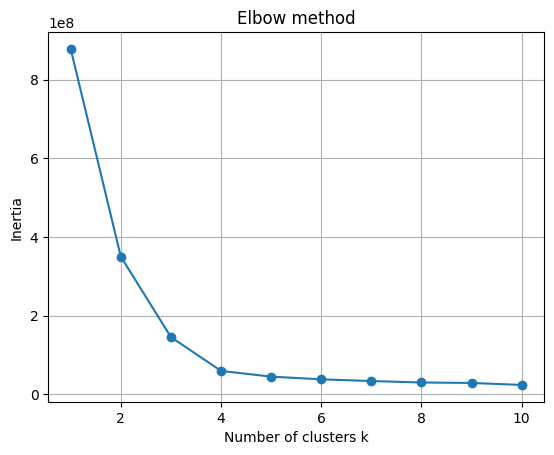

In [21]:
elbow_method(X)

Using elbow method best chooses will be 3 or 4.

# Another two algorithms

## AgglomerativeClustering

In [22]:
idx = np.random.choice(len(X), 10000, replace=False)
X_small = X.iloc[idx]

In [23]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_small)

In [24]:
Counter(labels_agg)

Counter({np.int64(0): 6798, np.int64(1): 1809, np.int64(2): 1393})

## GaussianMixture

In [26]:
from sklearn.mixture import GaussianMixture

In [27]:
X_scaled = StandardScaler().fit_transform(X)

In [28]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

In [29]:
Counter(labels_gmm)

Counter({np.int64(0): 30311, np.int64(2): 30710, np.int64(1): 29579})

In [31]:
cm = contingency_matrix(y, labels_gmm)
cm

array([[30086, 16528, 12507],
       [    8, 12880,  8621],
       [  217,   171,  9582]])